# Computer Vision, Assignment 1: Elements of Projective Geometry

In this assignment you will study the basics of projective geometry. You will study the representations of points lines and planes, as well as transformations and camera matrices.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade. All computer exercises not marked **OPTIONAL** are mandatory to complete. 

### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


In [1]:
# for creating responsive plots
# %matplotlib widget

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import cv2
import matplotlib.image as mpimg
from supplied import *

# Points in Homogeneous Coordinates

#### *Theoretical exercise 1* (see pdf)

## Computer Exercise 1
Write a function `pflat` that takes as input an array of shape $(m, n)$,
representing $n$ points in $\mathbb P^{m-1}$ in homogeneous coordinates. The output should be an $(m, n)$-array
containing the same homogeneous points, but where each point is normalized so that its last coordinate
is 1. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the
function to the points in `x2D` and `x3D` in the file `compEx1.mat`, and plot the result. It will be useful
for later to also create a function `plot_points_2D` that takes as input a $(2, n)$-array representing n
two dimensional points in Cartesian coordinates and plots them. And a similar `plot_points_3D` for
three dimensional points.

**Useful python commands:**

`ax.view_init(40, 35)` # to view a 3D plot from a specific angle

`ax.set_aspect('equal')` # makes sure that all axes have the same scale

In [2]:
def pflat(x):
    x = np.asarray(x)
    denom = x[-1, :]
    x_flat = x / denom
    return x_flat

def plot_points_2D(points):
    pts = np.asarray(points)
    if pts.shape[0] == 3:
        w = pts[-1, :]
        if not np.allclose(w, 1):
            pts = pts / w
        pts = pts[:2, :]

    x, y = pts[0, :], pts[1, :]
    ax = plt.gca()
    ax.plot(x, y, 'o', markersize=4)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(True)

def plot_points_3D(points, ax=None, kwargs={}):
    pts = np.asarray(points)
    if pts.shape[0] == 4:
        w = pts[-1, :]
        if not np.allclose(w, 1):
            pts = pts / w
        pts = pts[:3, :]

    X, Y, Z = pts[0, :], pts[1, :], pts[2, :]
    if ax is None:
        ax = plt.axes(projection='3d')
    ax.scatter(X, Y, Z, s=8, **kwargs)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(40, 35)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

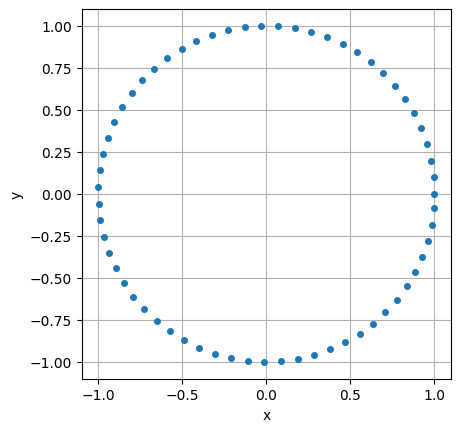

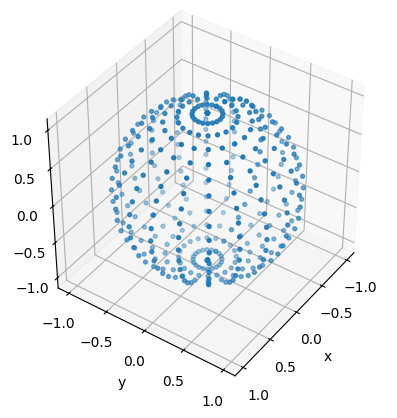

In [3]:
data = sp.io.loadmat('data/compEx1.mat')
x2D = data['x2D']
x3D = data['x3D']

plt.figure(1)
x2D_flat = pflat(x2D)
plot_points_2D(x2D_flat)
plt.show()

plt.figure(2)
x3D_flat = pflat(x3D)
plot_points_3D(x3D_flat)
plt.show()

# Lines

#### *Theoretical exercises: 2 and 3* (see pdf)

## Computer Exercise 2
Load and plot the image in `compEx2.jpg`. In the file `compEx2.mat` there are three pairs of image points.
Plot the image points in the same figure as the image. For each pair of points compute the line going through the points. 
Use the supplied function `rital` to plot the lines in the same image.
**Do these lines appear to be parallel (in 3D)?**
Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`.
Plot this point in the same image.

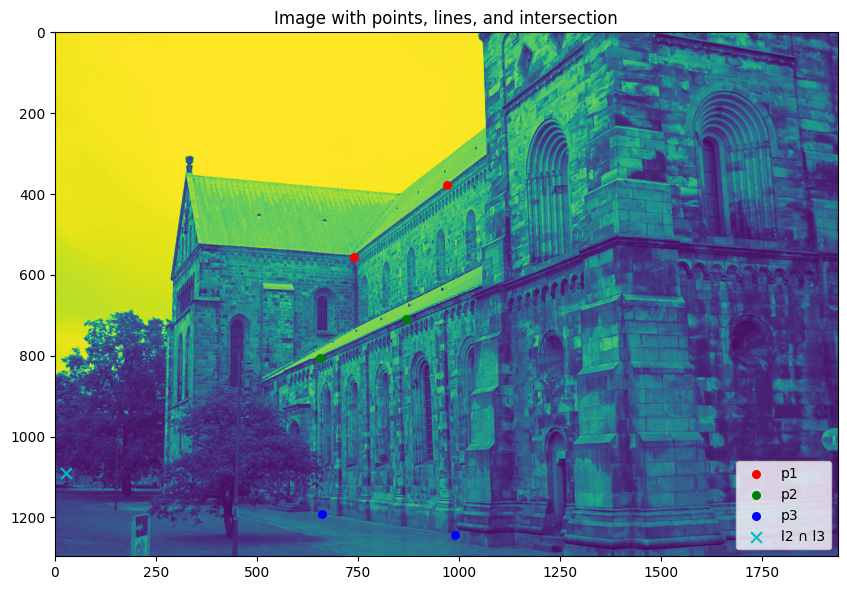

In [4]:
def to_homog(P):
    P = np.asarray(P)
    if P.ndim != 2:
        raise ValueError("Points must be a 2D array")
    if P.shape[0] not in (2, 3) and P.shape[1] in (2, 3):
        P = P.T
    if P.shape[0] == 2:
        P = np.vstack([P, np.ones((1, P.shape[1]))])
    elif P.shape[0] != 3:
        raise ValueError("Expected shape (2,N) or (3,N)")
    return P

def pflat(x):
    x = np.asarray(x, dtype=float)
    return x / x[-1]

def line_through(pair_3x2):
    return np.cross(pair_3x2[:, 0], pair_3x2[:, 1])

# load data
img = plt.imread("data/compEx2.jpg")
mat = sp.io.loadmat("data/compEx2.mat", squeeze_me=True)

# ensure each pair is 3x2 homogeneous with columns as points
p1 = to_homog(mat["p1"])
p2 = to_homog(mat["p2"])
p3 = to_homog(mat["p3"])

# lines from pairs
l1 = line_through(p1)
l2 = line_through(p2)
l3 = line_through(p3)

# intersection of lines from p2 and p3
v23 = np.cross(l2, l3)
v23 = pflat(v23)

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(img)

ax.scatter(p1[0]/p1[2], p1[1]/p1[2], c="r", s=30, label="p1")
ax.scatter(p2[0]/p2[2], p2[1]/p2[2], c="g", s=30, label="p2")
ax.scatter(p3[0]/p3[2], p3[1]/p3[2], c="b", s=30, label="p3")

rital(np.column_stack([l1, l2, l3]), "-")

ax.scatter([v23[0]], [v23[1]], c="c", s=60, marker="x", label="l2 ∩ l3")

h, w = img.shape[:2]
ax.set_xlim(0, w)
ax.set_ylim(h, 0)
ax.set_title("Image with points, lines, and intersection")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


The distance between a 2D-point $x=(x_1,x_2)$ in Cartesian coordinates and a line $l = (a,b,c)$ can be computed using the distance formula
\begin{equation}
d = \frac{|ax_1+bx_2+c|}{\sqrt{a^2+b^2}},
\end{equation}
see your linear algebra book.
Implement a function `point_line_distance_2D` that computes the distance between a point and a line.
Compute the distance between the first line and the intersection point. **Is it close to zero? Why/why not?**

In [5]:
def point_line_distance_2D(p, l):
    p = np.asarray(p).reshape(-1)
    l = np.asarray(l).reshape(-1)
    if p.size == 3:
        p = p / p[-1]          # dehomogenize to [x,y,1]
        x, y = p[0], p[1]
    elif p.size == 2:
        x, y = p

    a, b, c = l[:3]
    d = abs(a*x + b*y + c) / np.hypot(a, b)
    return float(d)

In [6]:
v23 = np.cross(l2, l3)
d = point_line_distance_2D(v23, l1)
print(f"Distance: {d}")

Distance: 8.269491356256719


### Your answer here: 

(*Include answers to all questions marked in bold.*)
### Yes, if the three image lines come from one family of parallel 3D directions, their projections should meet at a common vanishing point that lies on each line, so the ideal distance would be zero. The measured 8.27 residual is plausibly small and can be attributed to annotation noise, pixel quantization, and departures from the ideal pinhole model such as lens distortion, making the intersection near—but not exactly on l1.



# Projective Transformations

#### *Theoretical exercises: 4, 5, 6* (see pdf)

# The Pinhole Camera

#### *Theoretical exercise 7* (see pdf)

## Computer Exercise 3
Load and plot the images `compEx3im1.jpg` and `compEx3im2.jpg`.
The file `compEx3.mat` contains the camera matrices `P1`, `P2` and a point model `U` of the statue.

In order to visualize cameras in 3D it is useful to plot them as vectors pointing from the camera center in the direction of the principal axis.
Implement a function `camera_center_and_axis` that takes a camera matrix as input and outputs
the camera center and principal axis.
The camera center should be in Cartesian coordinates and the principal axis should be normalized to length 1.
Compute the camera centers and principal axes of the two cameras.

In [7]:
from scipy.linalg import rq

def camera_center_and_axis(P):

    P = np.asarray(P, dtype=float)

    # Camera center C as right nullspace of P (PC=0), then dehomogenize
    U, S, Vt = np.linalg.svd(P)
    C_h = Vt[-1]                    # homogeneous center
    C_h /= C_h[-1]                  # make last coord 1
    camera_center = C_h[:3]                     # Cartesian center

    # Principal axis: recover R from M = K R via RQ, then axis = R^T * e3
    M = P[:3, :3]
    K, R = rq(M)

    # Fix signs so K has positive diagonal and det(R)=+1
    T = np.diag(np.sign(np.diag(K)))
    K = K @ T
    R = T @ R
    if np.linalg.det(R) < 0:
        K = -K
        R = -R

    e3 = np.array([0.0, 0.0, 1.0])
    principal_axis = R.T @ e3
    principal_axis /= np.linalg.norm(principal_axis)

    return camera_center, principal_axis

Camera center 1:
[0. 0. 0.]

Principal axis 1:
[0.31292281 0.94608467 0.08368463]

Camera center 2:
[  6.6352039   14.84597919 -15.06911585]

Principal axis 2:
[0.03186384 0.34016542 0.93982561]


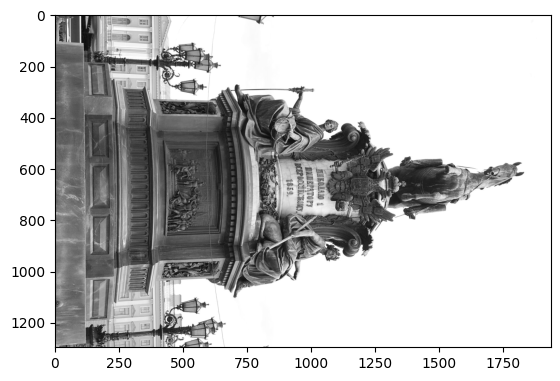

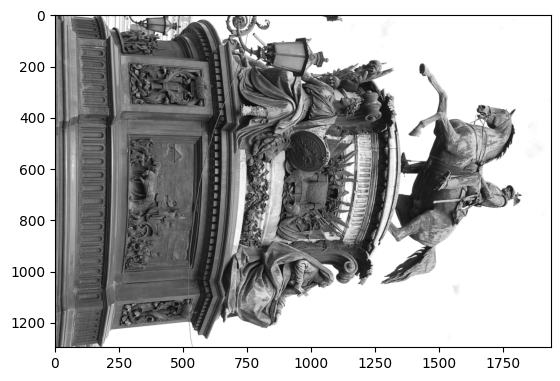

In [8]:
data = sp.io.loadmat('data/compEx3.mat')
U = data['U']
P1 = data['P1']
P2 = data['P2']
img1 = plt.imread('data/compEx3im1.jpg')
img2 = plt.imread('data/compEx3im2.jpg')

plt.figure(4) 
plt.imshow(img1, cmap='gray')
plt.figure(5)
plt.imshow(img2, cmap='gray')

# Compute the camera centers and principal axes of the two cameras
C1, pr1 = camera_center_and_axis(P1)
print(f"Camera center 1:\n{C1}")
print(f"\nPrincipal axis 1:\n{pr1}")

C2, pr2 = camera_center_and_axis(P2)
print(f"\nCamera center 2:\n{C2}")
print(f"\nPrincipal axis 2:\n{pr2}")

Next, implement a function `plot_camera` which takes a camera matrix and a scale $s$ as input and plots the principal axis of the camera scaled by $s$, from the camera center. 
Plot the 3D-points in `U` and the camera centers in the same 3D plot
(make sure that the 4th coordinate of `U` is one before you plot by using `pflat`.

**Useful python commands:**

`mpl_toolkits.mplot3d.axes3d.Axes3D.quiver` # can be used to plot arrows in a 3D plot

In [9]:
def plot_camera(camera_matrix, s, ax=None):
    if ax is None:
        ax = plt.axes(projection='3d')
    C, pr = camera_center_and_axis(camera_matrix)
    ax.quiver(C[0], C[1], C[2], pr[0], pr[1], pr[2],
              length=s, normalize=True, pivot='tail')
    ax.scatter([C[0]], [C[1]], [C[2]], s=40, marker='o')
    return ax

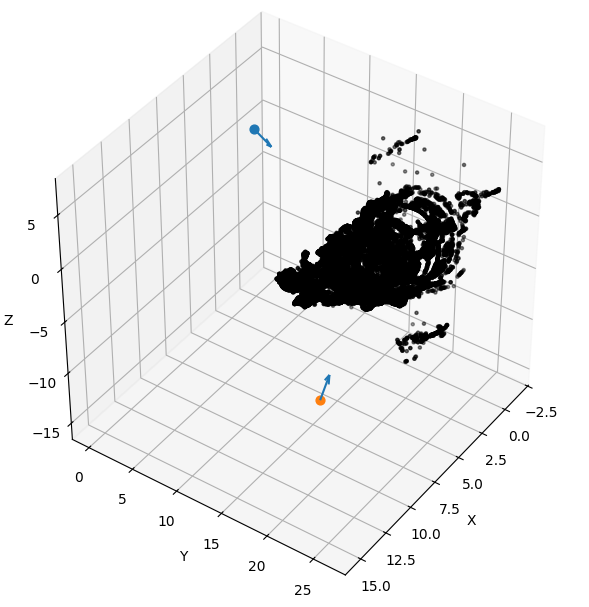

In [10]:
# Plot the 3D-points in U and the camera centers and principal axes in the same 3D plot

def pflat(X):
    X = np.asarray(X, dtype=float)
    return X / X[-1]

def camera_center_and_axis(P):
    # center = right nullspace of P
    _, _, Vt = np.linalg.svd(P)
    C_h = Vt[-1]
    C_h /= C_h[-1]
    C = C_h[:3]

    # principal axis direction in world coords: R^T * e3, recover R via RQ
    from scipy.linalg import rq
    M = P[:3, :3]
    K, R = rq(M)
    T = np.diag(np.sign(np.diag(K)))
    K = K @ T
    R = T @ R
    if np.linalg.det(R) < 0:
        K = -K
        R = -R
    pr = R.T @ np.array([0.0, 0.0, 1.0])
    pr /= np.linalg.norm(pr)
    return C, pr

U_cart = pflat(U)[:3, :]  # ensure 4th coord is 1, then take first 3 rows

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(U_cart[0], U_cart[1], U_cart[2], s=5, c='k')  # 3D points

# plot cameras (choose a scale relative to scene size)
scene_extent = np.ptp(U_cart, axis=1).max()
scale = 0.2 * scene_extent if scene_extent > 0 else 1.0

plot_camera(P1, scale, ax=ax)
plot_camera(P2, scale, ax=ax)

# make 3D view readable
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_box_aspect((1, 1, 1))
ax.view_init(40, 35)
plt.tight_layout()
plt.show()


Finally, project the points in `U` into the cameras `P1` and `P2` and plot the result in the same plots as the images.
**Does the result look reasonable?** 

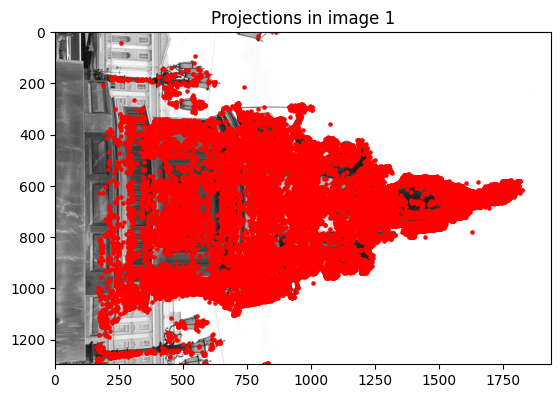

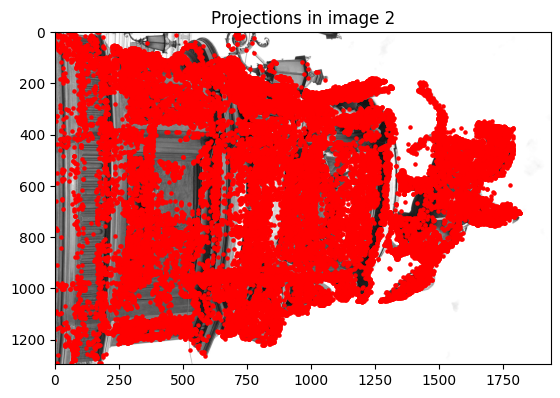

In [11]:
def pflat(X):
    X = np.asarray(X, dtype=float)
    return X / X[-1]

# Load data
data = sp.io.loadmat('data/compEx3.mat')
U  = data['U']            # 4xN homogeneous 3D points
P1 = data['P1']           # 3x4 camera matrix
P2 = data['P2']           # 3x4 camera matrix

img1 = plt.imread('data/compEx3im1.jpg')
img2 = plt.imread('data/compEx3im2.jpg')

# Ensure U has last row = 1
U = pflat(U)

# Project to each image: x ~ P U
x1 = pflat(P1 @ U)        # 3xN homogeneous image points -> normalize
x2 = pflat(P2 @ U)

# Plot on top of images
plt.figure(6)
plt.imshow(img1, cmap='gray')
plt.scatter(x1[0], x1[1], s=5, c='r')
plt.title('Projections in image 1')
plt.xlim(0, img1.shape[1]); plt.ylim(img1.shape[0], 0)

plt.figure(7)
plt.imshow(img2, cmap='gray')
plt.scatter(x2[0], x2[1], s=5, c='r')
plt.title('Projections in image 2')
plt.xlim(0, img2.shape[1]); plt.ylim(img2.shape[0], 0)

plt.show()

### Your answer here: 

(*Include answers to all questions marked in bold.*)
### Yes—this looks broadly reasonable, because the reprojected points should fall on visible scene structure and within the image bounds when overlaid on the original images.


#### *Theoretical exercise 8* (OPTIONAL, 10 optional points, see pdf)

## Computer Exercise 4 (OPTIONAL, 15 optional points)
Load and plot the image compEx4.jpg, which is an image of a poster. (Here the axes units are pixels.)
The file `compEx4.mat` contains the inner parameters `K`, the corner points of the poster and the 3D plane `v` that contains the poster.
The camera matrix for the camera that generated this image is 
\begin{equation}
P_1 = K [ I \ 0].
\end{equation}
The goal of this exercise is to create an image of the poster taken by a camera 
2m to the right of the original camera.

Start by plotting the corner points and the image in the same 2D-figure. (Make sure to set equal aspect ratio.) Note the scale on the axis. **Where is the origin of the image coordinate system located?**

In [ ]:

# Your code here


#### Your answer here: 
#

To be able to use the formulas derived in Theoretical Exercise 8, we must first ensure that we have calibrated cameras.
To do this, normalize the corner points by multiplying with $K^{-1}$ and plot them in a new 2D-figure. Use `ax.yaxis.set_inverted(True)` to make the y-axis point downwards (as for the previous image) and set equal aspect ratio.
Note the difference in scale compared to the previous figure. **Where is the origin of the image coordinate system located?**

In [ ]:

# Your code here


#### Your answer here: 
#

Since the inner parameters $K$ have been removed our calibrated camera is $[I \ 0]$.
Using the results from Theoretical Exercise 8, compute the 3D points in the plane `v` that project onto the corner points.
Compute the camera center and principal axis, and plot together with the 3D-points. Use the supplied function `axis3D_equal` to ensure equal aspect ratio. Does it look reasonable?

Next, compute a new camera with camera center in $(2,0,0)$ (2 units to the right of $P_1$)
and orientation 
\begin{equation}
R = \left( \begin{array}{ccc}
\cos(\pi/6) & 0 & \sin(\pi/6) \\
0 & 1 & 0 \\
-\sin(\pi/6) & 0 & \cos(\pi/6)
\end{array} \right)
\end{equation}
($-30$ degrees rotation around the y-axis. Note that the y-axis points down in the first image.)
Compute the new camera and plot in the same figure. (Don't forget to ensure equal aspect ratio.)


In [ ]:

# Your code here


Compute the homography in Theoretical Exercise 8 and transform the normalized corner points
to the new (virtual) image. Plot the transformed points (don't forget to divide by the third coordinate) in a new 2D-figure.
**Does the result look like you would expect it to when moving the camera like this?**
Also, project the 3D points into the same image using the camera matrix. Does this give the same result?

In [ ]:

# Your code here


#### Your answer here: 
#

We now have a homography that takes normalized points in the first camera and transforms them to normalized points in the second camera.
To remove the need for normalization we simply include the normalization in the homography.
If $\tilde{x} = K^{-1} x$ and $\tilde{y} = K^{-1} y$ then for the normalized points $\tilde{x}$ and $\tilde{y}$ we have
\begin{equation}
\tilde{y} \sim H \tilde{x} \Leftrightarrow  K^{-1}y \sim H K^{-1} x \Leftrightarrow y \sim K H K^{-1} x
\end{equation}
Therefore the total transformation is $H_{tot} = KHK^{-1}$.
Transform the original image and the corner points using the homography $H_{tot}$ and plot both in a new 2D-figure.


**Useful python commands:**

`transformed_img = cv2.warpPerspective(img, H_tot, (img.shape[1], img.shape[0]))` # can be used to apply the homography H_tot to the image

In [ ]:

# Your code here
